In [1]:
import numpy as np 
from sklearn.metrics import confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import AdaBoostClassifier
from sklearn.model_selection import train_test_split

import math
import pandas as pd 
import matplotlib.pyplot as plt

# import seaborn as sns
import sklearn.metrics as metrics
%matplotlib inline
import os
# from pandas_ml import ConfusionMatrix

In [2]:
df_train = pd.read_csv("./data/df_train.csv",index_col=0)

In [3]:
X_train, X_test, y_train, y_test = train_test_split(df_train.drop(['attack_type'],axis=1), df_train['attack_type'], test_size=0.2, random_state=42)

In [31]:
Y_train = y_train
Y_test = y_test
dict = {}
for i in Y_train:
    dict.update({i:dict.get(i,0)+1})
dict

{0: 61604, 1: 57209}

In [6]:
from sklearn.ensemble import AdaBoostClassifier
from imblearn.ensemble import EasyEnsembleClassifier

In [7]:
accuracy_test22 = np.empty((20))
accuracy_train22 = np.empty((20))

i = 1
while i<=20:
    model22 = EasyEnsembleClassifier(n_estimators=i*2, n_jobs=1,
             replacement=False, sampling_strategy='auto',verbose=0, warm_start=False,
                                     base_estimator=AdaBoostClassifier(n_estimators=10,random_state=42))
    model22.fit(X_train,Y_train)
    final_ans_test = model22.predict(X_test)
    acc = metrics.accuracy_score(Y_test,final_ans_test)
    accuracy_test22[i-1] = acc
    final_ans_train = model22.predict(X_train)
    acc = metrics.accuracy_score(Y_train,final_ans_train)
    accuracy_train22[i-1] = acc
    i = i+1
    print(i,end=" ")

2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
clf = DecisionTreeClassifier(max_depth=7)
model = clf.fit(X_train, Y_train)
Y_pred_test = model.predict(X_test)
Y_pred_train = model.predict(X_train)
acc_train = metrics.accuracy_score(Y_train,Y_pred_train)
acc_test = metrics.accuracy_score(Y_test,Y_pred_test)
print("accuracy = ",acc_train)
print("accuracy = ",acc_test)

accuracy_test = np.empty((20))
accuracy_train = np.empty((20))

i = 1
while i<=20:
    model = AdaBoostClassifier(DecisionTreeClassifier(max_depth=5),n_estimators=i*2,learning_rate=1.0,algorithm="SAMME.R")
    model.fit(X_train,Y_train)
    final_ans_test = model.predict(X_test)
    acc = metrics.accuracy_score(Y_test,final_ans_test)
    accuracy_test[i-1] = acc
    final_ans_train = model.predict(X_train)
    acc = metrics.accuracy_score(Y_train,final_ans_train)
    accuracy_train[i-1] = acc
    i = i+1

accuracy =  0.9733278344962252
accuracy =  0.9721586318340965


In [13]:
from imblearn.ensemble import BalancedBaggingClassifier
from imblearn.ensemble import BalancedRandomForestClassifier
from imblearn.ensemble import RUSBoostClassifier

In [14]:
accuracy_test3 = np.empty((20))
accuracy_train3 = np.empty((20))

i = 1
while i<=20:
    model3 = BalancedBaggingClassifier(n_estimators=i*2, random_state=42)
    model3.fit(X_train,Y_train)
    final_ans_test = model3.predict(X_test)
    acc = metrics.accuracy_score(Y_test,final_ans_test)
    accuracy_test3[i-1] = acc
    final_ans_train = model3.predict(X_train)
    acc = metrics.accuracy_score(Y_train,final_ans_train)
    accuracy_train3[i-1] = acc
    i = i+1

In [17]:
accuracy_test4 = np.empty((20))
accuracy_train4 = np.empty((20))

i = 1
while i<=20:
    model4 = BalancedRandomForestClassifier(n_estimators=i*2, random_state=42)
    model4.fit(X_train,Y_train)
    final_ans_test = model4.predict(X_test)
    acc = metrics.accuracy_score(Y_test,final_ans_test)
    accuracy_test4[i-1] = acc
    final_ans_train = model4.predict(X_train)
    acc = metrics.accuracy_score(Y_train,final_ans_train)
    accuracy_train4[i-1] = acc
    i = i+1

In [18]:

accuracy_test5 = np.empty((20))
accuracy_train5 = np.empty((20))

i = 1
while i<=20:
    model5 = RUSBoostClassifier(n_estimators=i*2, random_state=42, learning_rate=1.0, algorithm="SAMME.R")
    model5.fit(X_train,Y_train)
    final_ans_test = model5.predict(X_test)
    acc = metrics.accuracy_score(Y_test,final_ans_test)
    accuracy_test5[i-1] = acc
    final_ans_train = model5.predict(X_train)
    acc = metrics.accuracy_score(Y_train,final_ans_train)
    accuracy_train5[i-1] = acc
    i = i+1

In [29]:
sns.set()
# import warnings
# import math

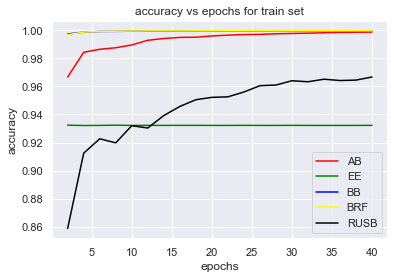

In [30]:
# Task 3

x = np.empty((20))
j = 1
while j<=20:
    x[j-1] = j*2
    j = j+1

# plt.plot(x, accuracy_test, label="adaboost test accuracy")
# plt.plot(x,accuracy_train,label="adaboost train accuracy")
# plt.plot(x, accuracy_test, c= 'red', label = "test", linestyle='-')
# plt.plot(x,accuracy_train, c= 'green', label ="train", linestyle='-')

plt.plot(x, accuracy_train, c= 'red', label = "AB", linestyle='-')
# plt.plot(x, accuracy_train2, c= 'green', label = "EE", linestyle='-')
plt.plot(x, accuracy_train22, c= 'green', label = "EE", linestyle='-')
plt.plot(x, accuracy_train3, c= 'blue', label = "BB", linestyle='-')
plt.plot(x, accuracy_train4, c= 'yellow', label = "BRF", linestyle='-')
plt.plot(x, accuracy_train5, c= 'black', label = "RUSB", linestyle='-')
# plt.plot(1,acc_test,'yo')
# plt.plot(1,acc_train,'go')
plt.xlabel('epochs')  
plt.ylabel('accuracy') 
  
# giving a title to my graph 
plt.title('accuracy vs epochs for train set') 
plt.legend(loc = 'lower right')
# function to show the plot 
plt.show() 


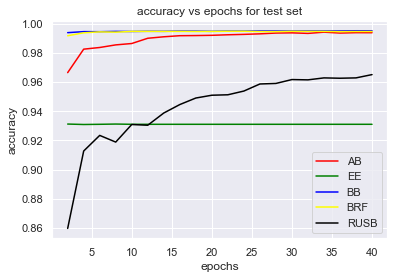

In [28]:
# Task 3

x = np.empty((20))
j = 1
while j<=20:
    x[j-1] = j*2
    j = j+1

# plt.plot(x, accuracy_test, label="adaboost test accuracy")
# plt.plot(x,accuracy_train,label="adaboost train accuracy")
# plt.plot(x, accuracy_test, c= 'red', label = "test", linestyle='-')
# plt.plot(x,accuracy_train, c= 'green', label ="train", linestyle='-')

plt.plot(x, accuracy_test, c= 'red', label = "AB", linestyle='-')
plt.plot(x, accuracy_test22, c= 'green', label = "EE", linestyle='-')
plt.plot(x, accuracy_test3, c= 'blue', label = "BB", linestyle='-')
plt.plot(x, accuracy_test4, c= 'yellow', label = "BRF", linestyle='-')
plt.plot(x, accuracy_test5, c= 'black', label = "RUSB", linestyle='-')
# plt.plot(1,acc_test,'yo')
# plt.plot(1,acc_train,'go')
plt.xlabel('epochs')  
plt.ylabel('accuracy') 
  
# giving a title to my graph 
plt.title('accuracy vs epochs for test set') 
plt.legend(loc = 'lower right')
# function to show the plot 
plt.show() 


In [25]:

def plot_AUC(expName,model,X_test,y_test):
    probs = model.predict_proba(X_test)
    preds = probs[:,1]
    fpr, tpr, threshold = metrics.roc_curve(y_test, preds)
    roc_auc = metrics.auc(fpr, tpr)

    plt.title(expName+' ROC curve')
    plt.plot(fpr, tpr, 'b', label = 'AUC = %0.10f' % roc_auc)
    plt.legend(loc = 'lower right')
    plt.plot([0, 1], [0, 1],'r--')
    plt.xlim([0, 1])
    plt.ylim([0, 1])
    plt.ylabel('True Positive Rate')
    plt.xlabel('False Positive Rate')
    plt.show()

In [131]:
import xgboost as xgb

In [132]:
model1 = AdaBoostClassifier(random_state=42)
model1.fit(X_train.fillna(0),y_train)

AdaBoostClassifier(random_state=42)

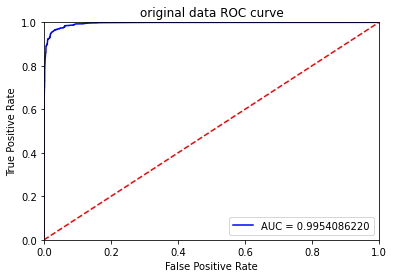

In [133]:
plot_AUC('original data',model1,X_test.fillna(0),y_test)

In [134]:
y_pred = model1.predict(X_test.fillna(0))
metrics.confusion_matrix(y_test,y_pred)

array([[15041,   409],
       [  594, 13660]], dtype=int64)

In [135]:
# cm = ConfusionMatrix(y_test,y_pred)
# cm.print_stats()


In [136]:
from imblearn.over_sampling import SMOTE 
sm = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = sm.fit_resample(X_train.fillna(0), y_train)
print('bad rate is: ',y_train_balanced.mean())

bad rate is:  0.5


In [137]:
model2 =AdaBoostClassifier(random_state=42)
model2.fit(X_train_balanced,y_train_balanced)

AdaBoostClassifier(random_state=42)

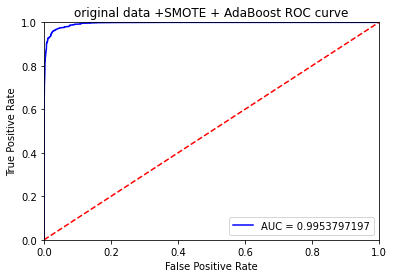

In [138]:
plot_AUC('original data +SMOTE + AdaBoost',model2,X_test.fillna(0),y_test)

In [139]:
y_pred = model2.predict(X_test.fillna(0))
metrics.confusion_matrix(y_test,y_pred)


array([[15015,   435],
       [  570, 13684]], dtype=int64)

In [140]:
from imblearn.ensemble import EasyEnsembleClassifier

In [141]:
model3 = EasyEnsembleClassifier(n_estimators=20, random_state=42, base_estimator=AdaBoostClassifier(random_state=42))
model3.fit(X_train.fillna(0),y_train)

EasyEnsembleClassifier(base_estimator=AdaBoostClassifier(random_state=42),
                       n_estimators=20, random_state=42)

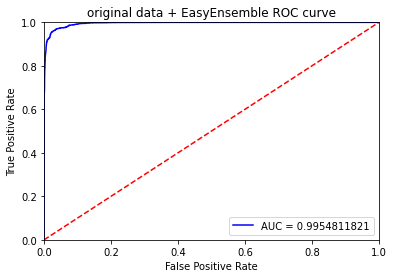

In [150]:
plot_AUC('original data + EasyEnsemble',model3,X_test.fillna(0),y_test)

In [151]:
y_pred = model2.predict(X_test.fillna(0))
metrics.confusion_matrix(y_test,y_pred)

array([[15015,   435],
       [  570, 13684]], dtype=int64)

In [152]:
total_1 = int(df_train['attack_type'].sum()*0.05)
df_train_extreme = pd.concat([df_train[df_train['attack_type']==1].sample(total_1,random_state=42),
                              df_train[df_train['attack_type']==0]])

In [153]:
X_train_ex, X_test_ex, y_train_ex, y_test_ex = train_test_split(
                                                    df_train_extreme.drop(['attack_type'],axis=1), 
                                                    df_train_extreme['attack_type'], test_size=0.2, 
                                                    random_state=42)

In [154]:
print(y_train_ex.mean(),y_test_ex.mean())

0.04452644145052015 0.04347017239240977


In [155]:
model_a = AdaBoostClassifier(random_state=42)
model_a.fit(X_train_ex.fillna(0),y_train_ex)

AdaBoostClassifier(random_state=42)

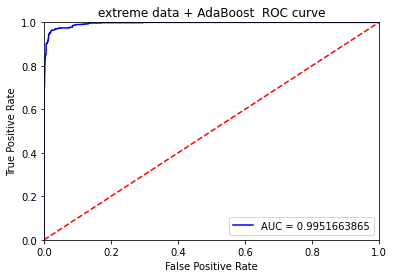

In [156]:
plot_AUC('extreme data + AdaBoost ',model_a,X_test_ex.fillna(0),y_test_ex)

In [157]:
y_pred_ex = model_a.predict(X_test_ex.fillna(0))
metrics.confusion_matrix(y_test_ex,y_pred_ex)


array([[15387,    38],
       [  138,   563]], dtype=int64)

In [158]:
model_b = EasyEnsembleClassifier(n_estimators=20, random_state=42, 
                                 base_estimator=AdaBoostClassifier(random_state=42))
model_b.fit(X_train_ex.fillna(0),y_train_ex)

EasyEnsembleClassifier(base_estimator=AdaBoostClassifier(random_state=42),
                       n_estimators=20, random_state=42)

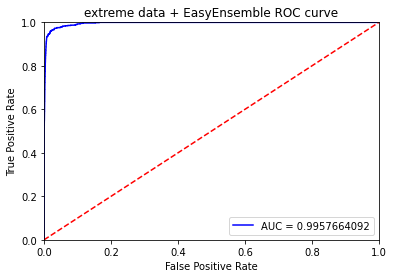

In [159]:
plot_AUC('extreme data + EasyEnsemble',model_b,X_test_ex.fillna(0),y_test_ex)

In [160]:
y_pred_ex = model_b.predict(X_test_ex.fillna(0))
metrics.confusion_matrix(y_test_ex,y_pred_ex)


array([[14983,   442],
       [   24,   677]], dtype=int64)